# Disease Risk Detection — Diabetes Classifier
### Detectron AI · Module 04

This notebook trains a **Logistic Regression** and **Gradient Boosting** classifier
on the well-known **Pima Indians Diabetes Dataset** structure to predict diabetes risk
from clinical features (glucose, BMI, age, blood pressure, etc.). It also implements the
transparent, points-based clinical risk score used in the live web demo for comparison.

*This is an educational project — not a diagnostic tool. Always consult a clinician.*


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

np.random.seed(11)


## 1. Synthetic clinical dataset

(Structured to mirror the real Pima Indians Diabetes Dataset's feature distribution.)

In [2]:
n = 700
age = np.random.randint(21, 81, n)
bmi = np.random.normal(29, 6, n).clip(15, 55)
glucose = np.random.normal(110, 30, n).clip(60, 250)
bp = np.random.normal(72, 12, n).clip(50, 140)
family_history = np.random.choice([0,1], n, p=[0.6, 0.4])
activity = np.random.choice([0,1], n, p=[0.45, 0.55])

# construct a realistic risk function with noise to generate labels
risk_logit = (
    0.04*(age-40) + 0.12*(bmi-28) + 0.06*(glucose-110) +
    0.03*(bp-72) + 1.1*family_history - 0.8*activity - 1.5
)
prob = 1 / (1 + np.exp(-risk_logit))
label = (np.random.rand(n) < prob).astype(int)

df = pd.DataFrame({
    "age": age, "bmi": bmi.round(1), "glucose": glucose.round(0),
    "blood_pressure": bp.round(0), "family_history": family_history,
    "physical_activity": activity, "diabetes": label
})
df.head()


,age,bmi,glucose,blood_pressure,family_history,physical_activity,diabetes
0,46,32.4,60.0,83.0,0,0,0
1,37,36.1,153.0,87.0,0,1,1
2,48,27.7,168.0,76.0,1,1,1
3,38,27.2,103.0,75.0,1,0,0
4,76,27.6,105.0,79.0,1,0,0


diabetes
0    0.629
1    0.371
Name: proportion, dtype: float64


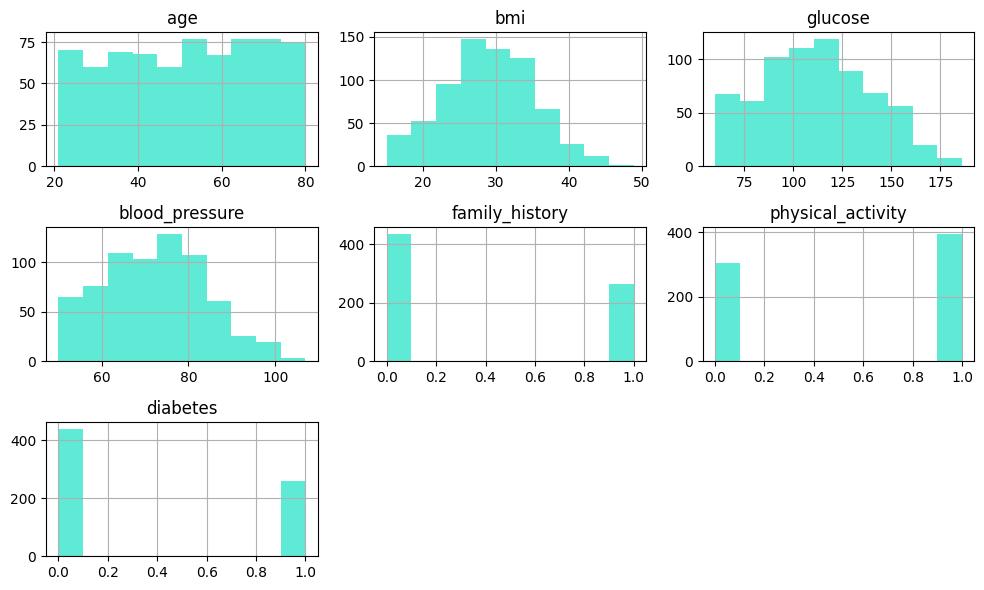

In [3]:
print(df["diabetes"].value_counts(normalize=True).round(3))
df.hist(figsize=(10,6), color="#5EEAD4")
plt.tight_layout()
plt.show()


## 2. Train / test split + scaling

In [4]:
features = ["age", "bmi", "glucose", "blood_pressure", "family_history", "physical_activity"]
X = df[features]
y = df["diabetes"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


## 3. Logistic Regression baseline

In [5]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_s, y_train)
proba_lr = logreg.predict_proba(X_test_s)[:, 1]
pred_lr = logreg.predict(X_test_s)

print("Logistic Regression")
print(classification_report(y_test, pred_lr))
print("ROC-AUC:", round(roc_auc_score(y_test, proba_lr), 4))


Logistic Regression
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       110
           1       0.75      0.71      0.73        65

    accuracy                           0.81       175
   macro avg       0.79      0.79      0.79       175
weighted avg       0.80      0.81      0.80       175

ROC-AUC: 0.8818


## 4. Gradient Boosting (stronger non-linear model)

In [6]:
gb = GradientBoostingClassifier(n_estimators=150, max_depth=3, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
proba_gb = gb.predict_proba(X_test)[:, 1]
pred_gb = gb.predict(X_test)

print("Gradient Boosting")
print(classification_report(y_test, pred_gb))
print("ROC-AUC:", round(roc_auc_score(y_test, proba_gb), 4))


Gradient Boosting
              precision    recall  f1-score   support

           0       0.78      0.82      0.80       110
           1       0.67      0.62      0.64        65

    accuracy                           0.74       175
   macro avg       0.72      0.72      0.72       175
weighted avg       0.74      0.74      0.74       175

ROC-AUC: 0.8158


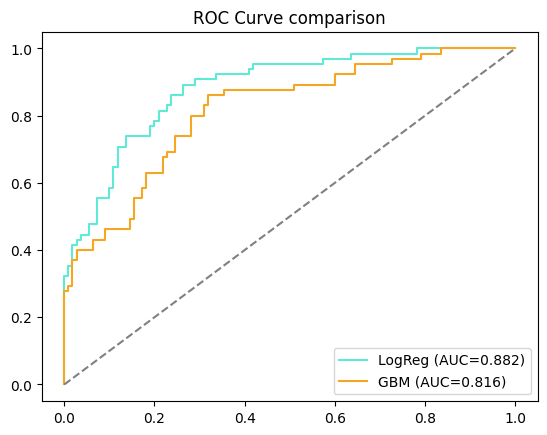

In [7]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, proba_lr)
fpr_gb, tpr_gb, _ = roc_curve(y_test, proba_gb)
plt.plot(fpr_lr, tpr_lr, label=f"LogReg (AUC={roc_auc_score(y_test, proba_lr):.3f})", color="#5EEAD4")
plt.plot(fpr_gb, tpr_gb, label=f"GBM (AUC={roc_auc_score(y_test, proba_gb):.3f})", color="#F5A623")
plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.legend(); plt.title("ROC Curve comparison")
plt.show()


## 5. Feature importance (Gradient Boosting)

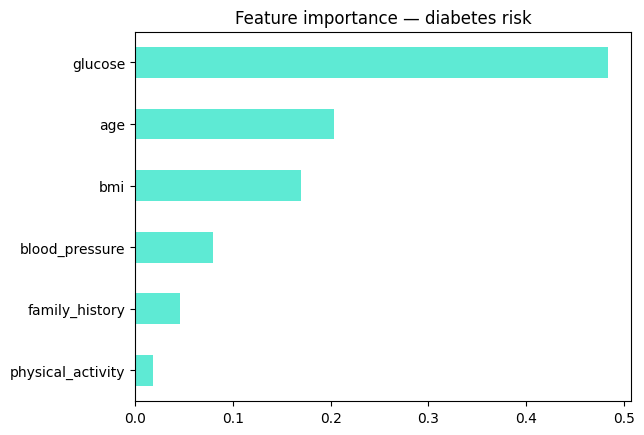

In [8]:
importances = pd.Series(gb.feature_importances_, index=features).sort_values()
importances.plot(kind="barh", color="#5EEAD4")
plt.title("Feature importance — diabetes risk")
plt.show()


## 6. Transparent clinical scoring rule (matches the live web demo)

In [9]:
def assess_diabetes_risk(age, bmi, glucose, bp, family_history, physical_activity):
    score = 0
    if age >= 60: score += 4
    elif age >= 45: score += 2
    if bmi >= 30: score += 4
    elif bmi >= 25: score += 2
    if glucose >= 126: score += 5
    elif glucose >= 100: score += 3
    if bp >= 140: score += 2
    if family_history: score += 3
    if not physical_activity: score += 2
    pct = score / 20 * 100
    level = "high" if pct >= 60 else "moderate" if pct >= 30 else "low"
    return score, level

score, level = assess_diabetes_risk(age=58, bmi=31, glucose=128, bp=138, family_history=True, physical_activity=False)
print(f"Score: {score}/20 -> Risk level: {level.upper()}")


Score: 16/20 -> Risk level: HIGH


## Notes

- Real diabetes prediction projects typically use the public **Pima Indians Diabetes
  Database** (768 patients, 8 features) — this notebook mirrors its structure with
  synthetic data so it runs standalone.
- The transparent scoring rule mirrors FINDRISC (Finnish Diabetes Risk Score) design
  principles: simple, additive, clinician-interpretable — useful for screening tools
  where explainability matters more than marginal accuracy gains.
